In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/comment-category-prediction-challenge/Sample.csv
/kaggle/input/competitions/comment-category-prediction-challenge/train.csv
/kaggle/input/competitions/comment-category-prediction-challenge/test.csv


# 8. MODEL COMPARISON

In [19]:
model_labels = {"lr": "Logistic Regression", "cnb": "Complement NB", "sgd": "SGD (log-loss)",
                 "lgbm": "LightGBM", "rf": "Random Forest"}

comparison = pd.DataFrame({
    "model": [model_labels[m] for m in val_probas],
    "val_accuracy": [acc_scores[m] for m in val_probas],
    "val_macro_f1": [f1_scores[m] for m in val_probas],
}).sort_values("val_macro_f1", ascending=False).reset_index(drop=True)
comparison


,model,val_accuracy,val_macro_f1
0,SGD (log-loss),0.887416,0.775450
1,LightGBM,0.891877,0.773231
2,Logistic Regression,0.888636,0.772795
3,Complement NB,0.692424,0.611403
4,Random Forest,0.785438,0.589596


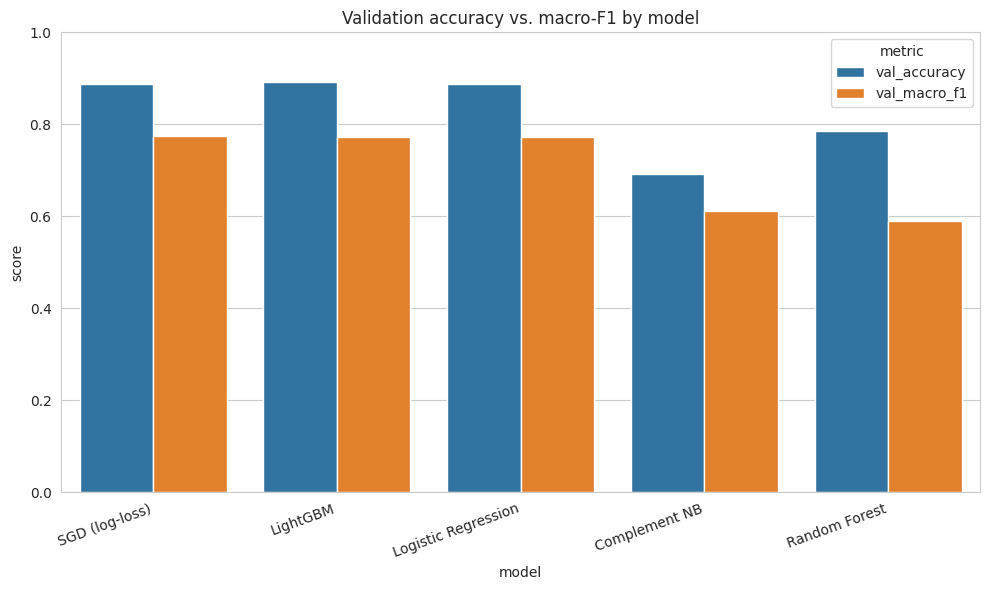

In [20]:
plot_df = comparison.melt(id_vars="model", value_vars=["val_accuracy", "val_macro_f1"],
                           var_name="metric", value_name="score")
plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x="model", y="score", hue="metric")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.title("Validation accuracy vs. macro-F1 by model")
plt.tight_layout()
plt.show()


**Reading this chart:** a model whose accuracy bar is much taller than its macro-F1 bar is leaning on the majority class rather than genuinely separating all four categories — that gap is exactly what made the earlier accuracy-weighted blend backfire. Models are ranked by macro-F1 below since that's what the leaderboard tracks.

## 8.1 Confusion matrix — best single model

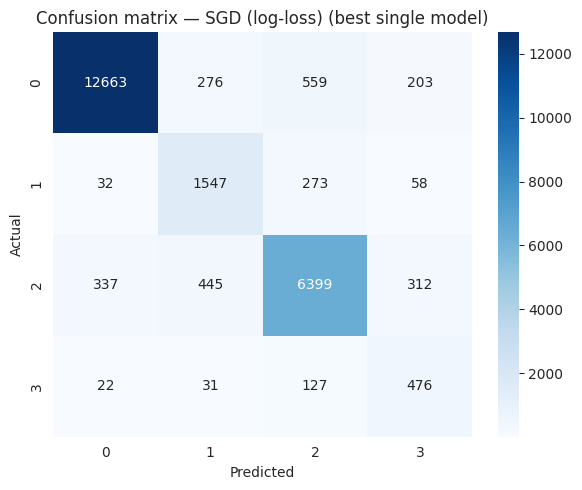

In [21]:
best_single = comparison.iloc[0]["model"]
best_key = [k for k, v in model_labels.items() if v == best_single][0]
cm = confusion_matrix(y_val, val_probas[best_key].argmax(axis=1))
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion matrix — {best_single} (best single model)")
plt.tight_layout()
plt.show()


# 9. ENSEMBLE — COORDINATE-ASCENT BLEND
Cycles through every model a few rounds; for each one, tries a fine grid of weights with everyone else held fixed and keeps whatever raises validation macro-F1. A model that never helps settles at weight 0, so the blend can only match or beat the best single model.

In [22]:
model_names = list(val_probas.keys())
weights = {m: 1.0 / len(model_names) for m in model_names}
grid = [round(x, 2) for x in np.arange(0.0, 1.01, 0.05)]

def macro_f1_of(w):
    total = sum(w.values())
    if total <= 0:
        return -1.0
    ens = sum((w[m] / total) * val_probas[m] for m in w)
    return f1_score(y_val, ens.argmax(axis=1), average="macro")

current_f1 = macro_f1_of(weights)
print(f"Start (equal weights): macro-F1 = {current_f1:.4f}")

for round_ in range(3):
    improved = False
    for m in model_names:
        best_w, best_f1_local = weights[m], current_f1
        for w in grid:
            trial = dict(weights); trial[m] = w
            f1_trial = macro_f1_of(trial)
            if f1_trial > best_f1_local:
                best_f1_local, best_w = f1_trial, w
        if best_w != weights[m]:
            weights[m] = best_w
            current_f1 = best_f1_local
            improved = True
    print(f"Round {round_ + 1}: macro-F1 = {current_f1:.4f}, weights = {{k: round(v,3) for k,v in weights.items()}}")
    if not improved:
        print("No further improvement, stopping early.")
        break

total_w = sum(weights.values())
weights = {m: w / total_w for m, w in weights.items()}
print("\nFinal ensemble weights:", {k: round(v, 3) for k, v in weights.items()})
ensemble_val = sum(weights[m] * val_probas[m] for m in weights)
ens_acc, ens_f1 = evaluate("FINAL ENSEMBLE (validation)", ensemble_val)
print("elapsed:", elapsed(), "s")


Start (equal weights): macro-F1 = 0.7931
Round 1: macro-F1 = 0.7957, weights = {k: round(v,3) for k,v in weights.items()}
Round 2: macro-F1 = 0.7990, weights = {k: round(v,3) for k,v in weights.items()}
Round 3: macro-F1 = 0.7993, weights = {k: round(v,3) for k,v in weights.items()}

Final ensemble weights: {'lr': np.float64(0.0), 'cnb': np.float64(0.233), 'sgd': np.float64(0.433), 'lgbm': np.float64(0.2), 'rf': np.float64(0.133)}
FINAL ENSEMBLE (validation) | val accuracy = 0.9018 | macro-F1 = 0.7993
elapsed: 212.8 s


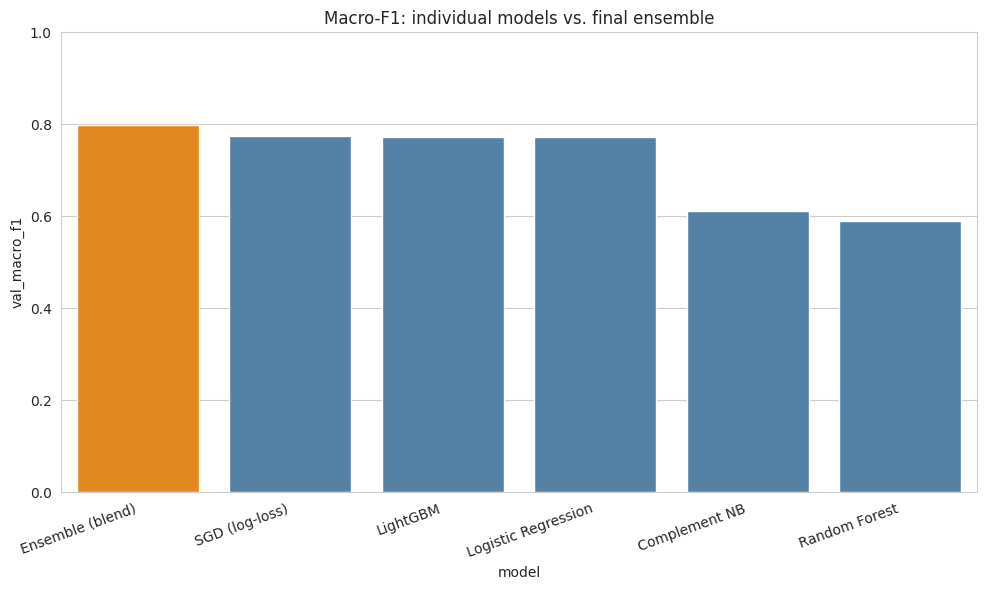

,model,val_accuracy,val_macro_f1
0,Ensemble (blend),0.901768,0.799289
1,SGD (log-loss),0.887416,0.775450
2,LightGBM,0.891877,0.773231
3,Logistic Regression,0.888636,0.772795
4,Complement NB,0.692424,0.611403
5,Random Forest,0.785438,0.589596


In [23]:
final_comparison = pd.concat([
    comparison,
    pd.DataFrame([{"model": "Ensemble (blend)", "val_accuracy": ens_acc, "val_macro_f1": ens_f1}])
], ignore_index=True).sort_values("val_macro_f1", ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 6))
colors = ["darkorange" if m == "Ensemble (blend)" else "steelblue" for m in final_comparison["model"]]
sns.barplot(data=final_comparison, x="model", y="val_macro_f1", palette=colors)
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.title("Macro-F1: individual models vs. final ensemble")
plt.tight_layout()
plt.show()

final_comparison


# 10. REFIT ON FULL TRAINING DATA, PREDICT TEST

In [24]:
fit_full = {}
if weights.get("lr", 0) > 0:
    lr.fit(X_sparse_train, y); fit_full["lr"] = lr.predict_proba(X_sparse_test)
if weights.get("cnb", 0) > 0:
    cnb.fit(Xw_train, y); fit_full["cnb"] = cnb.predict_proba(Xw_test)
if weights.get("sgd", 0) > 0:
    sgd.fit(X_sparse_train, y); fit_full["sgd"] = sgd.predict_proba(X_sparse_test)
if weights.get("lgbm", 0) > 0:
    lgbm.fit(X_sparse_train, y); fit_full["lgbm"] = lgbm.predict_proba(X_sparse_test)
if weights.get("rf", 0) > 0:
    rf.fit(X_num_train, y); fit_full["rf"] = rf.predict_proba(X_num_test)

active = {m: w for m, w in weights.items() if m in fit_full}
active_total = sum(active.values())
active = {m: w / active_total for m, w in active.items()}
print("Models actually refit and used:", active)

blend_test = sum(active[m] * fit_full[m] for m in active)
test_pred = blend_test.argmax(axis=1)
test_labels = le.inverse_transform(test_pred)
print("elapsed:", elapsed(), "s")


Models actually refit and used: {'cnb': np.float64(0.23333333333333334), 'sgd': np.float64(0.4333333333333334), 'lgbm': np.float64(0.2), 'rf': np.float64(0.13333333333333336)}
elapsed: 362.9 s


# 11. SUBMISSION

In [25]:
id_col = sample_sub.columns[0]
label_col = sample_sub.columns[1]
if id_col in test.columns:
    ids = test[id_col]
else:
    ids = np.arange(1, len(test) + 1)

submission = pd.DataFrame({id_col: ids, label_col: test_labels})
submission.to_csv("submission.csv", index=False)
print(submission.head())
print("Saved submission.csv with shape", submission.shape)
print("TOTAL RUNTIME:", round((time.time() - t_start) / 60, 2), "minutes")


   ID  label
0   1      2
1   2      2
2   3      0
3   4      0
4   5      2
Saved submission.csv with shape (102000, 2)
TOTAL RUNTIME: 6.05 minutes


**Summary**
- EDA confirmed heavy class imbalance, motivating `class_weight="balanced"` and macro-F1 as the model-selection metric throughout.
- 5 models trained: Logistic Regression, Complement NB, SGD, LightGBM, Random Forest — see Section 8 for the individual accuracy-vs-macro-F1 comparison and confusion matrix.
- Final prediction is a coordinate-ascent-weighted blend of whichever models actually improved validation macro-F1 (Section 9) — a model that didn't help settles at weight 0 and is skipped at refit time, so no wasted compute in Section 10.
- Modeling logic is unchanged from the working 0.796 submission; this version adds the EDA and comparison sections around it.